(2824, 48)
(1580, 48)
shape: (10, 2)
┌───────────┬──────┐
│ GameId    ┆ Week │
│ ---       ┆ ---  │
│ i64       ┆ i64  │
╞═══════════╪══════╡
│ 401752665 ┆ 1    │
│ 401752666 ┆ 1    │
│ 401752667 ┆ 1    │
│ 401752668 ┆ 1    │
│ 401752669 ┆ 1    │
│ 401752670 ┆ 1    │
│ 401752671 ┆ 1    │
│ 401752672 ┆ 1    │
│ 401752673 ┆ 1    │
│ 401752674 ┆ 1    │
└───────────┴──────┘

Pregame Tree
Games Evaluated: 1580
Accuracy: 0.6842
Log Loss: 0.5847
Brier Score: 0.2007

Pregame Neural Net
Games Evaluated: 1580
Accuracy: 0.6772
Log Loss: 0.5947
Brier Score: 0.2045

Summary:
shape: (2, 5)
┌────────────────────┬────────────────┬──────────┬──────────┬────────────┐
│ Experiment         ┆ GamesEvaluated ┆ Accuracy ┆ LogLoss  ┆ BrierScore │
│ ---                ┆ ---            ┆ ---      ┆ ---      ┆ ---        │
│ str                ┆ i64            ┆ f64      ┆ f64      ┆ f64        │
╞════════════════════╪════════════════╪══════════╪══════════╪════════════╡
│ Pregame Tree       ┆ 1580           ┆ 0.

ValueError: x and y must have same first dimension, but have shapes (15,) and (11,)

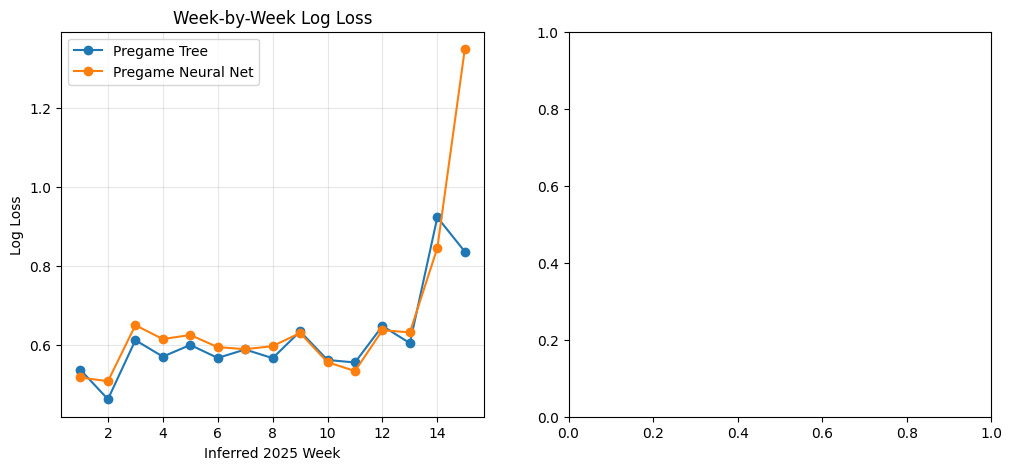

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from joblib import load
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

WP_MODEL_PATH = "wp_model_naive.pkl"
EPS = 1e-6


# ==========================================================
# 0. HELPERS
# ==========================================================
def safe_logit(p: np.ndarray) -> np.ndarray:
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p))


# ==========================================================
# 1. RAW HELPERS
# ==========================================================
def add_winner_loser(df: pl.DataFrame) -> pl.DataFrame:
    final_drives = df.filter(
        pl.col("DriveNumber") == pl.col("DriveNumber").max().over("GameId")
    )

    final_drives = (
        final_drives
        .with_columns(
            (pl.col("EndOffenseScore") > pl.col("EndDefenseScore")).alias("Offense_Won")
        )
        .with_columns(
            pl.when(pl.col("Offense_Won"))
            .then(pl.col("Offense"))
            .otherwise(pl.col("Defense"))
            .alias("winner"),

            pl.when(pl.col("Offense_Won"))
            .then(pl.col("Defense"))
            .otherwise(pl.col("Offense"))
            .alias("loser"),
        )
        .select(["GameId", "winner", "loser"])
    )

    return df.join(final_drives, on="GameId", how="left")


def add_basic_game_state(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df.with_columns(
            (pl.col("Offense") == pl.col("winner")).alias("OffenseWon"),
            (
                60 * (
                    15 * (pl.lit(4) - pl.col("StartPeriod")) +
                    pl.col("StartTime Minutes")
                ) + pl.col("StartTime Seconds")
            ).alias("SecondsRemaining"),
            (pl.col("StartOffenseScore") - pl.col("StartDefenseScore")).alias("ScoreDifferential")
        )
    )


def add_win_probability_and_wp_added(df: pl.DataFrame, wp_model_path: str) -> pl.DataFrame:
    model = load(wp_model_path)

    features = [
        "StartYardline",
        "IsHomeOffense",
        "ScoreDifferential",
        "SecondsRemaining",
    ]

    X = df.select(features).to_numpy()
    wp = model.predict_proba(X)[:, 1]

    df = df.with_columns(pl.Series("win_prob", wp))

    df = df.sort(["GameId", "DriveNumber"]).with_columns(
        pl.col("win_prob").shift(-1).over("GameId").alias("next_wp_raw")
    )

    df = df.with_columns(
        pl.when(pl.col("next_wp_raw").is_null())
        .then(pl.when(pl.col("OffenseWon")).then(1.0).otherwise(0.0))
        .otherwise(pl.col("next_wp_raw"))
        .alias("next_wp")
    )

    win_prob = np.clip(df["win_prob"].to_numpy(), EPS, 1 - EPS)
    next_wp = np.clip(df["next_wp"].to_numpy(), EPS, 1 - EPS)

    logit_before = safe_logit(win_prob)
    logit_after = safe_logit(next_wp)

    df = df.with_columns([
        pl.Series("drive_wp_added", next_wp - win_prob),
        pl.Series("drive_logodds_added", logit_after - logit_before),
    ])

    return df


# ==========================================================
# 2. BUILD ONE ROW PER GAME
# ==========================================================
def build_games(df: pl.DataFrame) -> pl.DataFrame:
    home_teams = (
        df.filter(pl.col("IsHomeOffense") == True)
        .group_by("GameId")
        .agg(pl.col("Offense").first().alias("HomeTeam"))
    )

    away_teams = (
        df.filter(pl.col("IsHomeOffense") == False)
        .group_by("GameId")
        .agg(pl.col("Offense").first().alias("AwayTeam"))
    )

    outcomes = (
        df.group_by("GameId")
        .agg(
            pl.col("winner").first().alias("winner"),
            pl.col("loser").first().alias("loser")
        )
    )

    games = (
        home_teams
        .join(away_teams, on="GameId", how="inner")
        .join(outcomes, on="GameId", how="inner")
        .with_columns(
            (pl.col("winner") == pl.col("HomeTeam")).cast(pl.Int8).alias("HomeWon")
        )
        .sort("GameId")
    )

    return games


def infer_weeks_from_gameid_order(games: pl.DataFrame) -> pl.DataFrame:
    games = games.sort("GameId")

    team_games_played = {}
    inferred_weeks = []

    for row in games.iter_rows(named=True):
        home = row["HomeTeam"]
        away = row["AwayTeam"]

        home_prior = team_games_played.get(home, 0)
        away_prior = team_games_played.get(away, 0)

        week = max(home_prior, away_prior) + 1
        inferred_weeks.append(week)

        team_games_played[home] = home_prior + 1
        team_games_played[away] = away_prior + 1

    return games.with_columns(pl.Series("Week", inferred_weeks))


# ==========================================================
# 3. LOAD YEAR
# ==========================================================
def load_year(year: int) -> pl.DataFrame:
    df = pl.read_csv(f"{year}drives.csv")

    required = [
        "GameId", "DriveNumber", "Offense", "Defense",
        "Yards", "StartYardsToGoal", "EndOffenseScore", "StartOffenseScore",
        "EndDefenseScore", "StartDefenseScore",
        "StartYardline", "IsHomeOffense",
        "StartPeriod", "StartTime Minutes", "StartTime Seconds"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{year}drives.csv is missing columns: {missing}")

    df = add_winner_loser(df)
    df = add_basic_game_state(df)
    df = add_win_probability_and_wp_added(df, WP_MODEL_PATH)

    df = df.with_columns(
        (pl.col("EndOffenseScore") - pl.col("StartOffenseScore")).alias("points_added"),
        pl.when(pl.col("StartYardsToGoal") > 0)
          .then((pl.col("Yards") / pl.col("StartYardsToGoal")).clip(0, 1))
          .otherwise(None)
          .alias("yards_pct"),
        pl.lit(year).alias("Season")
    )

    games = build_games(df)
    games = infer_weeks_from_gameid_order(games).select(["GameId", "Week"])
    df = df.join(games, on="GameId", how="left")
    return df


# ==========================================================
# 4. PREGAME FEATURES
# ==========================================================
pregame_feature_cols = [
    "home_off_games",
    "home_def_games",
    "away_off_games",
    "away_def_games",

    "home_off_yards_per_drive",
    "home_off_yards_per_drive_std",
    "home_off_points_per_drive",
    "home_off_yards_pct",
    "home_off_wp_added",
    "home_off_logodds_added",
    "home_off_positive_rate",

    "home_def_yards_allowed_per_drive",
    "home_def_yards_allowed_per_drive_std",
    "home_def_points_allowed_per_drive",
    "home_def_yards_pct_allowed",
    "home_def_wp_added_allowed",
    "home_def_logodds_allowed",
    "home_def_positive_rate_allowed",

    "away_off_yards_per_drive",
    "away_off_yards_per_drive_std",
    "away_off_points_per_drive",
    "away_off_yards_pct",
    "away_off_wp_added",
    "away_off_logodds_added",
    "away_off_positive_rate",

    "away_def_yards_allowed_per_drive",
    "away_def_yards_allowed_per_drive_std",
    "away_def_points_allowed_per_drive",
    "away_def_yards_pct_allowed",
    "away_def_wp_added_allowed",
    "away_def_logodds_allowed",
    "away_def_positive_rate_allowed",

    "diff_off_yards_per_drive",
    "diff_off_points_per_drive",
    "diff_off_yards_pct",
    "diff_off_wp_added",
    "diff_off_logodds_added",

    "diff_def_yards_allowed_per_drive",
    "diff_def_points_allowed_per_drive",
    "diff_def_yards_pct_allowed",
    "diff_def_wp_added_allowed",
    "diff_def_logodds_allowed",
]


def build_team_game_history(prior_drives: pl.DataFrame) -> pl.DataFrame:
    offense = (
        prior_drives.group_by("Offense")
        .agg(
            pl.n_unique("GameId").alias("off_games"),
            pl.len().alias("off_drives"),
            pl.mean("Yards").alias("off_yards_per_drive"),
            pl.std("Yards").fill_null(0.0).alias("off_yards_per_drive_std"),
            pl.mean("points_added").alias("off_points_per_drive"),
            pl.mean("yards_pct").alias("off_yards_pct"),
            pl.mean("drive_wp_added").alias("off_wp_added"),
            pl.mean("drive_logodds_added").alias("off_logodds_added"),
            (pl.col("drive_logodds_added") > 0).mean().alias("off_positive_rate"),
        )
        .rename({"Offense": "Team"})
    )

    defense = (
        prior_drives.group_by("Defense")
        .agg(
            pl.n_unique("GameId").alias("def_games"),
            pl.len().alias("def_drives_faced"),
            pl.mean("Yards").alias("def_yards_allowed_per_drive"),
            pl.std("Yards").fill_null(0.0).alias("def_yards_allowed_per_drive_std"),
            pl.mean("points_added").alias("def_points_allowed_per_drive"),
            pl.mean("yards_pct").alias("def_yards_pct_allowed"),
            pl.mean("drive_wp_added").alias("def_wp_added_allowed"),
            pl.mean("drive_logodds_added").alias("def_logodds_allowed"),
            (pl.col("drive_logodds_added") > 0).mean().alias("def_positive_rate_allowed"),
        )
        .rename({"Defense": "Team"})
    )

    return offense.join(defense, on="Team", how="inner")


def make_pregame_row(game_row: dict, prior_drives: pl.DataFrame) -> dict | None:
    team_hist = build_team_game_history(prior_drives)

    home = game_row["HomeTeam"]
    away = game_row["AwayTeam"]

    home_hist = team_hist.filter(pl.col("Team") == home)
    away_hist = team_hist.filter(pl.col("Team") == away)

    if home_hist.height == 0 or away_hist.height == 0:
        return None

    h = home_hist.to_dicts()[0]
    a = away_hist.to_dicts()[0]

    row = {
        "GameId": game_row["GameId"],
        "Season": game_row["Season"],
        "Week": game_row["Week"],
        "HomeTeam": home,
        "AwayTeam": away,
        "HomeWon": game_row["HomeWon"],

        "home_off_games": h["off_games"],
        "home_def_games": h["def_games"],
        "away_off_games": a["off_games"],
        "away_def_games": a["def_games"],

        "home_off_yards_per_drive": h["off_yards_per_drive"],
        "home_off_yards_per_drive_std": h["off_yards_per_drive_std"],
        "home_off_points_per_drive": h["off_points_per_drive"],
        "home_off_yards_pct": h["off_yards_pct"],
        "home_off_wp_added": h["off_wp_added"],
        "home_off_logodds_added": h["off_logodds_added"],
        "home_off_positive_rate": h["off_positive_rate"],

        "home_def_yards_allowed_per_drive": h["def_yards_allowed_per_drive"],
        "home_def_yards_allowed_per_drive_std": h["def_yards_allowed_per_drive_std"],
        "home_def_points_allowed_per_drive": h["def_points_allowed_per_drive"],
        "home_def_yards_pct_allowed": h["def_yards_pct_allowed"],
        "home_def_wp_added_allowed": h["def_wp_added_allowed"],
        "home_def_logodds_allowed": h["def_logodds_allowed"],
        "home_def_positive_rate_allowed": h["def_positive_rate_allowed"],

        "away_off_yards_per_drive": a["off_yards_per_drive"],
        "away_off_yards_per_drive_std": a["off_yards_per_drive_std"],
        "away_off_points_per_drive": a["off_points_per_drive"],
        "away_off_yards_pct": a["off_yards_pct"],
        "away_off_wp_added": a["off_wp_added"],
        "away_off_logodds_added": a["off_logodds_added"],
        "away_off_positive_rate": a["off_positive_rate"],

        "away_def_yards_allowed_per_drive": a["def_yards_allowed_per_drive"],
        "away_def_yards_allowed_per_drive_std": a["def_yards_allowed_per_drive_std"],
        "away_def_points_allowed_per_drive": a["def_points_allowed_per_drive"],
        "away_def_yards_pct_allowed": a["def_yards_pct_allowed"],
        "away_def_wp_added_allowed": a["def_wp_added_allowed"],
        "away_def_logodds_allowed": a["def_logodds_allowed"],
        "away_def_positive_rate_allowed": a["def_positive_rate_allowed"],
    }

    row["diff_off_yards_per_drive"] = row["home_off_yards_per_drive"] - row["away_off_yards_per_drive"]
    row["diff_off_points_per_drive"] = row["home_off_points_per_drive"] - row["away_off_points_per_drive"]
    row["diff_off_yards_pct"] = row["home_off_yards_pct"] - row["away_off_yards_pct"]
    row["diff_off_wp_added"] = row["home_off_wp_added"] - row["away_off_wp_added"]
    row["diff_off_logodds_added"] = row["home_off_logodds_added"] - row["away_off_logodds_added"]

    row["diff_def_yards_allowed_per_drive"] = (
        row["home_def_yards_allowed_per_drive"] - row["away_def_yards_allowed_per_drive"]
    )
    row["diff_def_points_allowed_per_drive"] = (
        row["home_def_points_allowed_per_drive"] - row["away_def_points_allowed_per_drive"]
    )
    row["diff_def_yards_pct_allowed"] = (
        row["home_def_yards_pct_allowed"] - row["away_def_yards_pct_allowed"]
    )
    row["diff_def_wp_added_allowed"] = (
        row["home_def_wp_added_allowed"] - row["away_def_wp_added_allowed"]
    )
    row["diff_def_logodds_allowed"] = (
        row["home_def_logodds_allowed"] - row["away_def_logodds_allowed"]
    )

    return row


def build_pregame_dataset(all_drives: pl.DataFrame) -> pl.DataFrame:
    games = build_games(all_drives).select(["GameId", "HomeTeam", "AwayTeam", "HomeWon"])
    weeks = all_drives.select(["GameId", "Season", "Week"]).unique()

    games = (
        games.join(weeks, on="GameId", how="inner")
        .sort(["Season", "Week", "GameId"])
    )

    rows = []

    for g in games.iter_rows(named=True):
        prior_drives = all_drives.filter(
            (pl.col("Season") < g["Season"]) |
            ((pl.col("Season") == g["Season"]) & (pl.col("Week") < g["Week"]))
        )

        if prior_drives.height == 0:
            continue

        row = make_pregame_row(g, prior_drives)
        if row is not None:
            rows.append(row)

    return pl.DataFrame(rows).sort(["Season", "Week", "GameId"])


# ==========================================================
# 5. TRAIN MODELS
# ==========================================================
def fit_pregame_tree(train_games: pl.DataFrame):
    X = train_games.select(pregame_feature_cols).to_numpy()
    y = train_games["HomeWon"].to_numpy()

    model = HistGradientBoostingClassifier(
        max_iter=120,
        learning_rate=0.08,
        max_depth=3,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    )
    model.fit(X, y)
    return model


def fit_pregame_nn(train_games: pl.DataFrame):
    X = train_games.select(pregame_feature_cols).to_numpy()
    y = train_games["HomeWon"].to_numpy()

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(24, 12),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=120,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10
        ))
    ])

    model.fit(X, y)
    return model


# ==========================================================
# 6. EVALUATE
# ==========================================================
def evaluate_model(model, games_df: pl.DataFrame) -> pl.DataFrame:
    X = games_df.select(pregame_feature_cols).to_numpy()
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)

    return games_df.with_columns(
        pl.Series("pred_home_win_prob", probs),
        pl.Series("pred_home_win", preds),
        (pl.Series("pred_home_win", preds) == pl.col("HomeWon")).cast(pl.Int8).alias("correct")
    )


def summarize_results(name: str, results: pl.DataFrame) -> dict:
    y = results["HomeWon"].to_numpy()
    p = results["pred_home_win_prob"].to_numpy()
    pred = results["pred_home_win"].to_numpy()

    return {
        "Experiment": name,
        "GamesEvaluated": len(y),
        "Accuracy": accuracy_score(y, pred),
        "LogLoss": log_loss(y, p),
        "BrierScore": brier_score_loss(y, p),
    }


def weekly_metrics(results: pl.DataFrame) -> pl.DataFrame:
    rows = []

    for week in sorted(results["Week"].unique().to_list()):
        wk = results.filter(pl.col("Week") == week)

        y_true = wk["HomeWon"].to_numpy()
        y_prob = wk["pred_home_win_prob"].to_numpy()

        rows.append({
            "Week": week,
            "n_games": len(y_true),
            "accuracy": accuracy_score(y_true, (y_prob >= 0.5).astype(int)),
            "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
            "brier": brier_score_loss(y_true, y_prob),
        })

    return pl.DataFrame(rows).sort("Week")


# ==========================================================
# 7. LOAD SEASONS
# ==========================================================
data_2023 = load_year(2023)
data_2024 = load_year(2024)
data_2025 = load_year(2025)

train_drives = pl.concat([data_2023, data_2024])
all_drives = pl.concat([data_2023, data_2024, data_2025])

train_games = build_pregame_dataset(train_drives)
test_games = build_pregame_dataset(all_drives).filter(pl.col("Season") == 2025)

print(train_games.shape)
print(test_games.shape)
print(test_games.select(["GameId", "Week"]).head(10))


# ==========================================================
# 8. RUN MODELS
# ==========================================================
experiments = {
    "Pregame Tree": fit_pregame_tree,
    "Pregame Neural Net": fit_pregame_nn,
}

all_results = {}
summaries = []

for name, fit_fn in experiments.items():
    print(f"\n{name}")
    model = fit_fn(train_games)
    results = evaluate_model(model, test_games)

    all_results[name] = results
    s = summarize_results(name, results)
    summaries.append(s)

    print(f"Games Evaluated: {s['GamesEvaluated']}")
    print(f"Accuracy: {s['Accuracy']:.4f}")
    print(f"Log Loss: {s['LogLoss']:.4f}")
    print(f"Brier Score: {s['BrierScore']:.4f}")

summary_df = pl.DataFrame(summaries)
print("\nSummary:")
print(summary_df)



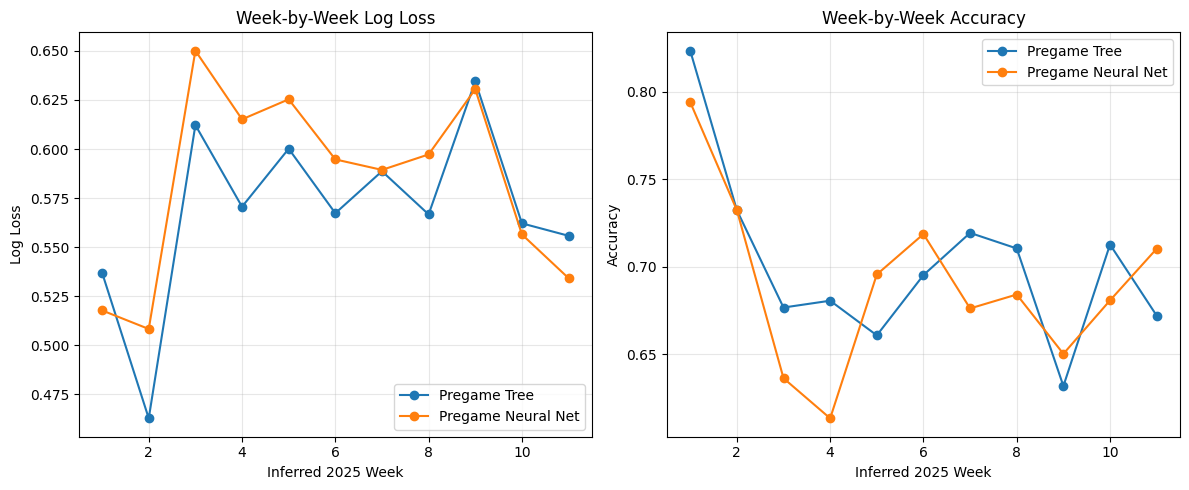

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, res in all_results.items():
    wk = weekly_metrics(res)
    plt.plot(
        wk["Week"].to_numpy()[:11],
        wk["log_loss"].to_numpy()[:11],
        marker="o",
        label=name
    )
plt.xlabel("Inferred 2025 Week")
plt.ylabel("Log Loss")
plt.title("Week-by-Week Log Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
for name, res in all_results.items():
    wk = weekly_metrics(res)
    plt.plot(
        wk["Week"].to_numpy()[:11],
        wk["accuracy"].to_numpy()[:11],
        marker="o",
        label=name
    )
plt.xlabel("Inferred 2025 Week")
plt.ylabel("Accuracy")
plt.title("Week-by-Week Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()